In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 2.0 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 1.5 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.4 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
x=[
    [1,5],
    [2,3],
    [3,6],
    [4,8],
    [5,1],
    [6,9],
    [6,5],
    [7,8],
    [9,9],
    [9,2]
]
y=[1,1,0,1,0,1,0,1,0,0]
df=pd.DataFrame(x,columns=['x1','x2'])

In [3]:
df['output']=y

In [4]:
df.head()

,x1,x2,output
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0


In [6]:
df['Weights']=1/df.shape[0]

In [7]:
df

,x1,x2,output,Weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [9]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [36]:
dt1=DecisionTreeClassifier(max_depth=1)

In [37]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [38]:
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

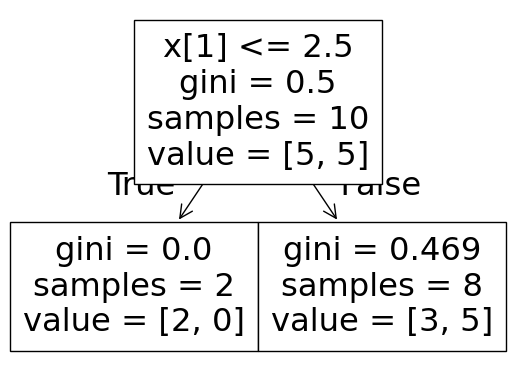

In [39]:
plot_tree(dt1)

In [40]:
df['y_pred']=dt1.predict(X)

In [41]:
df

,x1,x2,output,Weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


<Axes: >

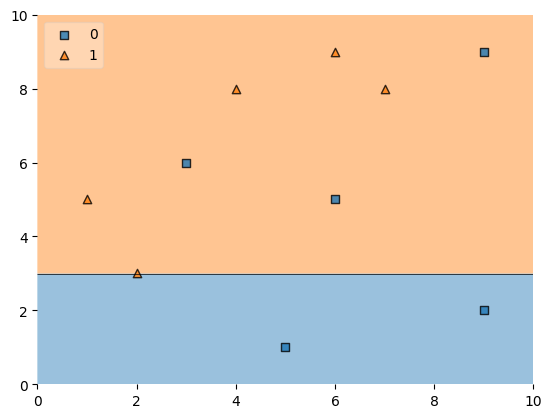

In [42]:
plot_decision_regions(X,y,clf=dt1, legend=2)

In [64]:
def error(row):
    if row['output'] != row['y_pred']:
        return row['Weights']
    else:
        return 0


In [65]:
df['error'] = df.apply(error, axis=1)

In [67]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/error)

In [71]:
alpha1= calculate_model_weight(df['error'].sum())
alpha1

np.float64(0.4236489301936017)

In [132]:
def update_weights(row,alpha):
    if row['output']==row['y_pred']:
        return row['Weights']*np.exp(-alpha)
    else:
        return row['Weights']*np.exp(alpha)

In [133]:
#df['updated_weights'] = df.apply(update_weights,axis=1)
df['updated_weights'] = df.apply(lambda row: update_weights(row, alpha1), axis=1)

In [134]:
df['updated_weights'].sum()

np.float64(0.9165151389911682)

In [135]:
df['normalized']=df['updated_weights']/df['updated_weights'].sum()

In [136]:
df['normalized'].sum()

np.float64(0.9999999999999999)

In [84]:
df['cumsum_upper']=np.cumsum(df['normalized'])

In [85]:
df['cumsum_lower']=df['cumsum_upper']-df['normalized']

In [94]:
df[['x1','x2','output','Weights','y_pred','updated_weights','normalized','cumsum_lower','cumsum_upper']]

,x1,x2,output,Weights,y_pred,updated_weights,normalized,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065465,0.071429,0.000000,0.071429
1,2,3,1,0.1,1,0.065465,0.071429,0.071429,0.142857
2,3,6,0,0.1,1,0.152753,0.166667,0.142857,0.309524
3,4,8,1,0.1,1,0.065465,0.071429,0.309524,0.380952
4,5,1,0,0.1,0,0.065465,0.071429,0.380952,0.452381
5,6,9,1,0.1,1,0.065465,0.071429,0.452381,0.523810
6,6,5,0,0.1,1,0.152753,0.166667,0.523810,0.690476
7,7,8,1,0.1,1,0.065465,0.071429,0.690476,0.761905
8,9,9,0,0.1,1,0.152753,0.166667,0.761905,0.928571
9,9,2,0,0.1,0,0.065465,0.071429,0.928571,1.000000


In [95]:
def create_new_index(df):
    indices=[]
    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper']>a and a>row['cumsum_lower']:
                indices.append(index)
    return indices
        

In [99]:
new_index=create_new_index(df)

In [100]:
new_index

[6, 6, 3, 4, 1, 5, 0, 5, 6, 1]

In [101]:
second_df=df.iloc[new_index,[0,1,2,3]]

In [102]:
second_df

,x1,x2,output,Weights
6,6,5,0,0.1
6,6,5,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
1,2,3,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
5,6,9,1,0.1
6,6,5,0,0.1
1,2,3,1,0.1


In [120]:
X2=second_df.iloc[:,0:2].values
y2=second_df.iloc[:,2].values

In [121]:
dt2=DecisionTreeClassifier(max_depth=1)

In [122]:
dt2.fit(X2,y2)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 4.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.625, 0.5, '  False')]

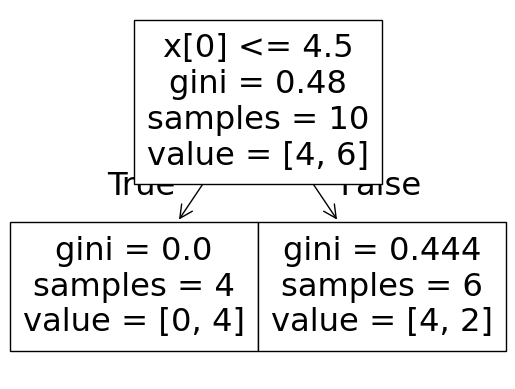

In [123]:
plot_tree(dt2)

<Axes: >

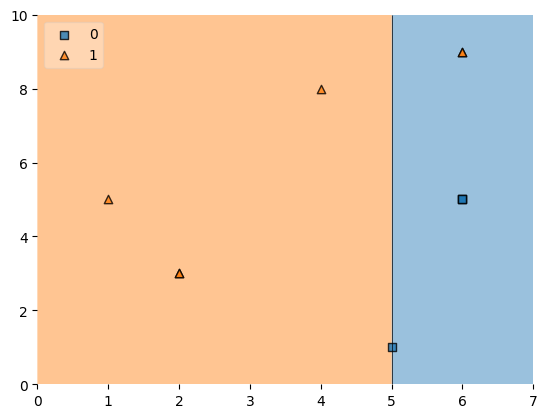

In [124]:
plot_decision_regions(X2, y2, clf=dt2, legend=2)

In [127]:
second_df['y_pred']=dt2.predict(X2)

In [128]:
second_df['error']=second_df.apply(error,axis=1)

In [130]:
alpha2=calculate_model_weight(second_df['error'].sum())
alpha2

np.float64(0.6931471805599453)

In [140]:
second_df['new_weights'] = second_df.apply(lambda row: update_weights(row, alpha2), axis=1)
second_df['new_weights'].sum()

np.float64(0.8)

In [141]:
second_df['normalized_wt']=second_df['new_weights']/second_df['new_weights'].sum()

In [146]:
second_df['cumsum_upper']=np.cumsum(second_df['normalized_wt'])

In [147]:
second_df['cumsum_lower']=second_df['cumsum_upper']-second_df['normalized_wt']

In [153]:
second_df[['x1','x2','output','Weights','y_pred','new_weights','cumsum_lower','cumsum_upper']]

,x1,x2,output,Weights,y_pred,new_weights,cumsum_lower,cumsum_upper
6,6,5,0,0.1,0,0.05,0.0000,0.0625
6,6,5,0,0.1,0,0.05,0.0625,0.1250
3,4,8,1,0.1,1,0.05,0.1250,0.1875
4,5,1,0,0.1,0,0.05,0.1875,0.2500
1,2,3,1,0.1,1,0.05,0.2500,0.3125
5,6,9,1,0.1,0,0.20,0.3125,0.5625
0,1,5,1,0.1,1,0.05,0.5625,0.6250
5,6,9,1,0.1,0,0.20,0.6250,0.8750
6,6,5,0,0.1,0,0.05,0.8750,0.9375
1,2,3,1,0.1,1,0.05,0.9375,1.0000


In [156]:
index2=create_new_index(df)
index2

[5, 8, 8, 5, 3, 8, 9, 9, 4, 5]

In [159]:
third_df=df.iloc[index2,[0,1,2,3]]
third_df

,x1,x2,output,Weights
5,6,9,1,0.1
8,9,9,0,0.1
8,9,9,0,0.1
5,6,9,1,0.1
3,4,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
4,5,1,0,0.1
5,6,9,1,0.1


In [160]:
X=third_df.iloc[:,0:2]
y=third_df.iloc[:,2]

In [162]:
dt3=DecisionTreeClassifier(max_depth=1)

In [163]:
dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [164]:
third_df['y_pred']=dt3.predict(X)

In [166]:
third_df

,x1,x2,output,Weights,y_pred
5,6,9,1,0.1,1
8,9,9,0,0.1,0
8,9,9,0,0.1,0
5,6,9,1,0.1,1
3,4,8,1,0.1,1
8,9,9,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
4,5,1,0,0.1,1
5,6,9,1,0.1,1


In [168]:
third_df['error']=third_df.apply(error,axis=1)
third_df['error'].sum()

np.float64(0.1)

In [169]:
alpha3=calculate_model_weight(third_df['error'].sum())

In [172]:
third_df['new_weights']=third_df.apply(lambda row: update_weights(row, alpha3), axis=1)
third_df['new_weights'].sum()

np.float64(0.6)

In [175]:
third_df['normalized']=third_df['new_weights']/third_df['new_weights'].sum()
third_df['normalized'].sum()

np.float64(1.0000000000000002)

In [176]:
third_df['cumsum_upper']=np.cumsum(third_df['normalized'])

In [180]:
third_df['cumsum_lower']=df['cumsum_upper']-df['normalized']
third_df[['x1','x2','output','Weights','y_pred','new_weights','normalized','cumsum_lower','cumsum_upper']]

,x1,x2,output,Weights,y_pred,new_weights,normalized,cumsum_lower,cumsum_upper
5,6,9,1,0.1,1,0.033333,0.055556,0.452381,0.055556
8,9,9,0,0.1,0,0.033333,0.055556,0.761905,0.111111
8,9,9,0,0.1,0,0.033333,0.055556,0.761905,0.166667
5,6,9,1,0.1,1,0.033333,0.055556,0.452381,0.222222
3,4,8,1,0.1,1,0.033333,0.055556,0.309524,0.277778
8,9,9,0,0.1,0,0.033333,0.055556,0.761905,0.333333
9,9,2,0,0.1,0,0.033333,0.055556,0.928571,0.388889
9,9,2,0,0.1,0,0.033333,0.055556,0.928571,0.444444
4,5,1,0,0.1,1,0.300000,0.500000,0.380952,0.944444
5,6,9,1,0.1,1,0.033333,0.055556,0.452381,1.000000


In [181]:
print(alpha1,alpha2,alpha3)

0.4236489301936017 0.6931471805599453 1.0986122886681098


In [182]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [183]:
dt2.predict(query)

array([1])

In [184]:
dt3.predict(query)

C:\Users\Priti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [185]:
alpha1*1+alpha2*1+alpha3*1

np.float64(2.2154083994216567)

In [186]:
np.sign(2.215)

np.float64(1.0)